# Analisis Decision Tree pada Dataset *Higher Education Students Performance Evaluation*

**Tools utama:** Orange Data Mining  
**Model:** Decision Tree  
**Dataset:** Higher Education Students Performance Evaluation, UCI Machine Learning Repository  
**Target klasifikasi:** `GRADE`

Mengklasifikasikan performa mahasiswa berdasarkan variabel target `GRADE` menggunakan algoritma **Decision Tree**. Hasil utama yang dijelaskan meliputi alur kerja Orange, pengaturan data, evaluasi model, confusion matrix, interpretasi Tree Viewer


## 1. Tujuan Analisis

Tujuan analisis ini adalah membangun model klasifikasi menggunakan algoritma **Decision Tree** untuk memprediksi kategori nilai akhir mahasiswa (`GRADE`). Dataset yang digunakan berisi atribut-atribut mahasiswa yang berkaitan dengan latar belakang, kebiasaan belajar, dan faktor akademik. Dalam analisis ini, `GRADE` dijadikan sebagai variabel target, sedangkan kolom-kolom lain digunakan sebagai variabel prediktor.

Secara metodologis, analisis ini termasuk **supervised learning** karena model dilatih menggunakan data yang sudah memiliki label kelas. Jenis tugasnya adalah **multi-class classification**, sebab variabel target `GRADE` memiliki delapan kelas, yaitu kelas 0 sampai 7.



## 2. Pengaturan Data di Orange

Pada widget **File** di Orange, pengaturan kolom dilakukan sebagai berikut:

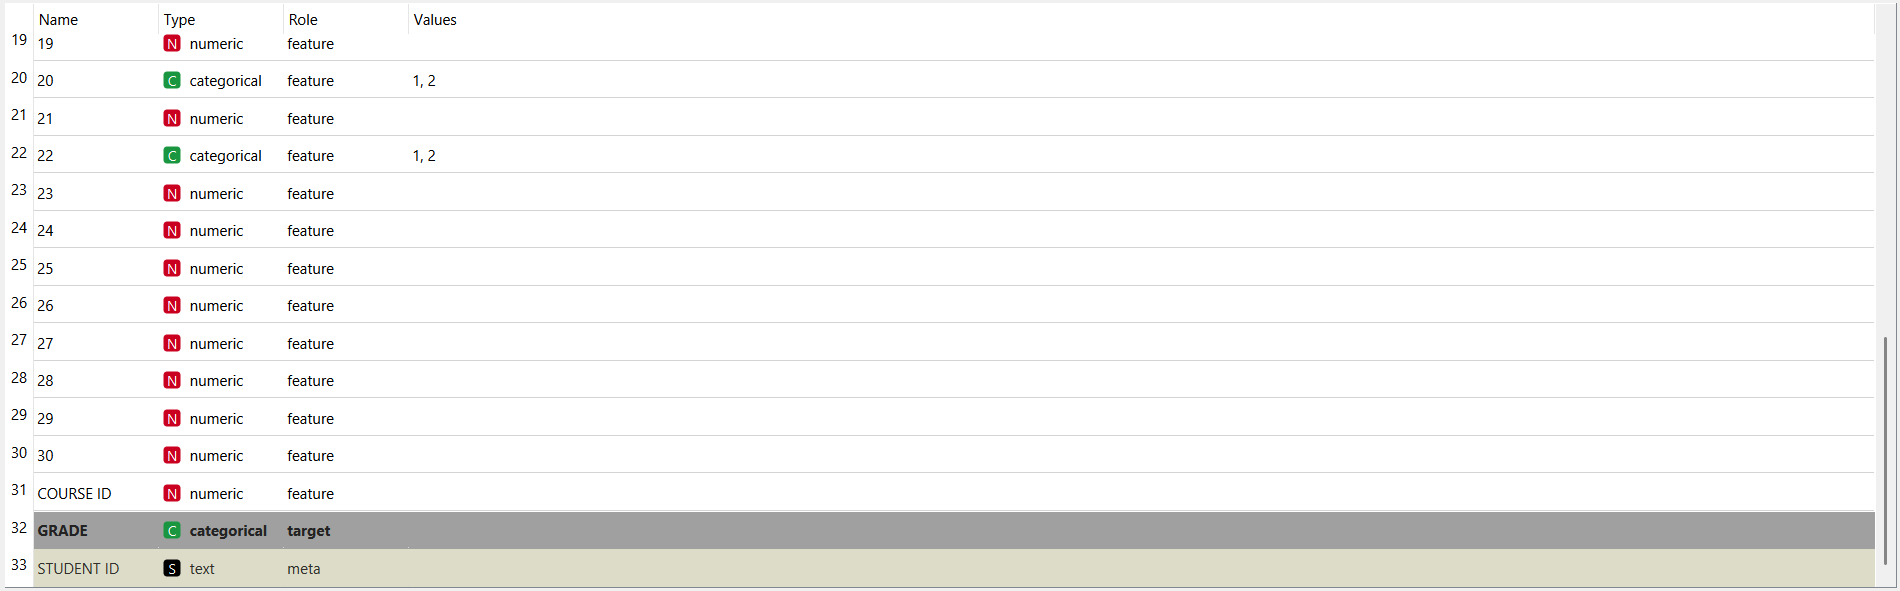

| Kolom | Peran di Orange | Alasan |
|---|---|---|
| `GRADE` | Target | Variabel yang ingin diprediksi oleh model |
| `STUDENT ID` | Meta | Hanya identitas mahasiswa, bukan variabel prediktor |
| Kolom `1` sampai `30` | Feature | Variabel prediktor |
| `COURSE ID` | Feature | Informasi mata kuliah yang ikut digunakan dalam pemodelan |





## 3. Workflow Analisis di Orange

Workflow yang digunakan dalam Orange adalah:

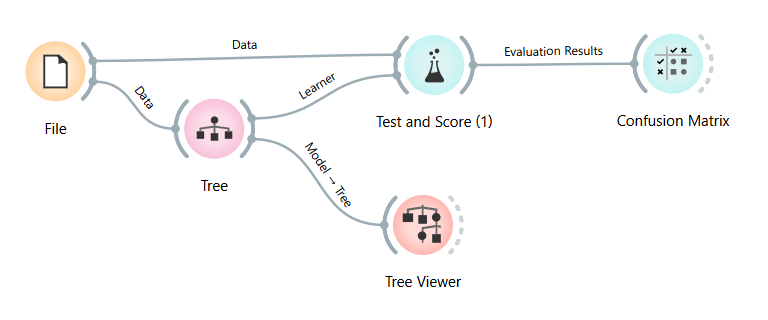

`File → Tree → Test and Score → Confusion Matrix`  
`Tree → Tree Viewer`

Alur tersebut menunjukkan bahwa data dari widget **File** digunakan untuk membangun model **Decision Tree** melalui widget **Tree**. Selanjutnya, model dievaluasi melalui **Test and Score**, hasil kesalahan klasifikasi dianalisis melalui **Confusion Matrix**, dan struktur pohon keputusan dilihat melalui **Tree Viewer**.



## 4. Pengaturan Algoritma Decision Tree

Pengaturan model Decision Tree pada Orange adalah sebagai berikut:

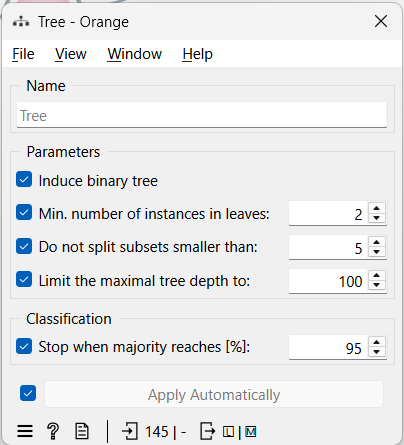
| Parameter | Nilai yang digunakan |
|---|---:|
| Induce binary tree | Aktif |
| Minimum number of instances in leaves | 2 |
| Do not split subsets smaller than | 5 |
| Limit maximal tree depth | 100 |
| Stop when majority reaches | 95% |

Pengaturan tersebut memungkinkan pohon membentuk banyak cabang keputusan. Pada hasil Tree Viewer, model membentuk **89 nodes** dan **45 leaves**. Jumlah node dan leaf yang cukup banyak menunjukkan bahwa pohon keputusan cukup kompleks untuk ukuran dataset yang hanya berisi 145 data.



## 5. Evaluasi Model Decision Tree

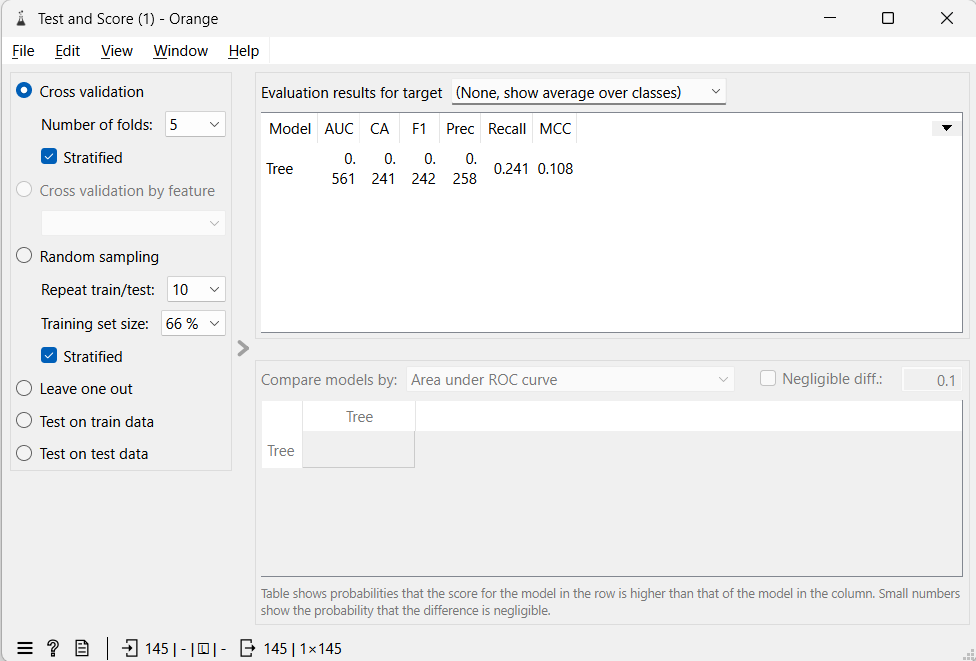

Evaluasi dilakukan menggunakan **5-fold stratified cross-validation**. Metode ini dipilih karena jumlah data pada kelas terkecil hanya 8, sehingga 10-fold stratified cross-validation tidak dapat dijalankan secara tepat. Dengan 5-fold stratified cross-validation, proporsi kelas tetap dipertahankan pada setiap fold sehingga evaluasi menjadi lebih stabil dibanding pembagian acak biasa.

Hasil evaluasi yang diperoleh dari widget **Test and Score** adalah sebagai berikut.



### Interpretasi Hasil Evaluasi

Nilai **CA/Accuracy sebesar 0,241** menunjukkan bahwa model hanya mampu memprediksi kelas `GRADE` dengan benar sekitar **24,1%** dari seluruh data. Nilai **F1-score sebesar 0,242** menunjukkan bahwa keseimbangan antara precision dan recall masih rendah. Nilai **Precision sebesar 0,258** berarti ketepatan model dalam memberikan prediksi kelas masih terbatas, sedangkan **Recall sebesar 0,241** menunjukkan bahwa kemampuan model mengenali kelas aktual juga masih rendah.

Nilai **AUC sebesar 0,561** menunjukkan kemampuan pembeda model masih berada pada tingkat rendah sampai sedang. Sementara itu, nilai **MCC sebesar 0,108** memperlihatkan bahwa hubungan antara hasil prediksi dan kelas aktual masih lemah. Dengan demikian, Decision Tree pada dataset ini lebih tepat diposisikan sebagai model untuk melihat pola awal, bukan sebagai model prediksi yang kuat.



## 6. Confusion Matrix

Confusion matrix digunakan untuk melihat kelas mana yang berhasil diprediksi dengan benar dan kelas mana yang sering tertukar. Baris menunjukkan kelas aktual, sedangkan kolom menunjukkan kelas prediksi. Angka pada diagonal utama menunjukkan jumlah prediksi yang benar.


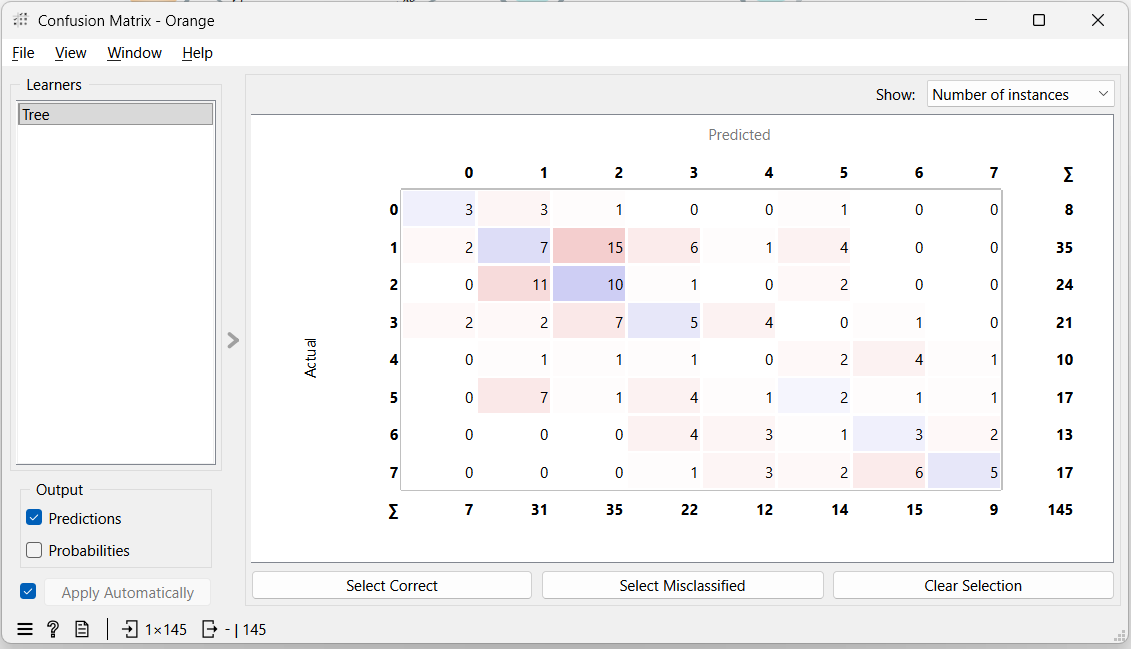


### Interpretasi Confusion Matrix

Berdasarkan confusion matrix, model Decision Tree hanya berhasil memprediksi **35 data dengan benar dari total 145 data**. Kelas yang paling banyak diprediksi benar adalah **GRADE 2** sebanyak 10 data. Sebaliknya, **GRADE 4** tidak berhasil diprediksi dengan benar sama sekali.

Kesalahan klasifikasi paling menonjol terjadi pada beberapa pola berikut. Pertama, data aktual **GRADE 1** banyak diprediksi sebagai **GRADE 2**, yaitu sebanyak 15 data. Kedua, data aktual **GRADE 2** banyak diprediksi sebagai **GRADE 1**, yaitu sebanyak 11 data. Ketiga, data aktual **GRADE 7** cukup sering diprediksi sebagai **GRADE 6**, yaitu sebanyak 6 data. Pola ini menunjukkan bahwa model masih kesulitan membedakan kelas-kelas yang berdekatan atau memiliki karakteristik yang mirip.



## 7. Interpretasi Tree Viewer

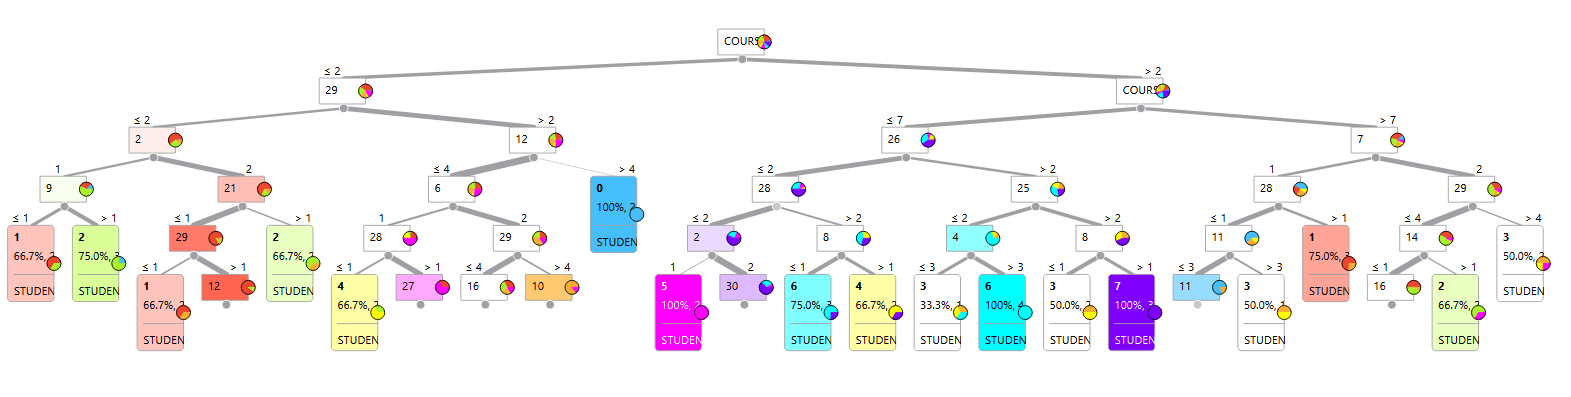

Hasil Tree Viewer menunjukkan bahwa model Decision Tree membentuk:

| Komponen | Hasil |
|---|---:|
| Nodes | 89 |
| Leaves | 45 |
| Depth yang ditampilkan | 6 levels |

Pada struktur pohon, node awal terlihat menggunakan `COURSE ID` sebagai pemisah pertama. Hal ini menunjukkan bahwa informasi mata kuliah menjadi variabel awal yang digunakan model untuk membagi data mahasiswa. Setelah itu, pohon menggunakan beberapa atribut lain seperti kolom `29`, `26`, `28`, dan atribut numerik lain untuk membentuk aturan klasifikasi.

Namun, karena nama variabel dalam dataset masih berupa kode angka, interpretasi substantif setiap cabang perlu dikaitkan dengan data dictionary dari sumber dataset. Secara teknis, semakin banyak node dan leaves, semakin kompleks pohon yang terbentuk. Kompleksitas ini belum tentu menghasilkan performa yang baik, terbukti dari accuracy model yang masih rendah.



## 8. Kesimpulan

Berdasarkan hasil analisis, algoritma Decision Tree menghasilkan accuracy sebesar **0,241**, F1-score sebesar **0,242**, precision sebesar **0,258**, recall sebesar **0,241**, AUC sebesar **0,561**, dan MCC sebesar **0,108**. Hasil ini menunjukkan bahwa performa model masih rendah dalam mengklasifikasikan `GRADE` mahasiswa.

Confusion matrix menunjukkan bahwa model hanya mampu memprediksi **35 dari 145 data** secara benar. Kesalahan klasifikasi paling banyak terjadi antara GRADE 1 dan GRADE 2, serta antara GRADE 6 dan GRADE 7. Tree Viewer juga menunjukkan bahwa struktur pohon cukup kompleks dengan **89 nodes** dan **45 leaves**, tetapi kompleksitas tersebut belum menghasilkan akurasi yang tinggi.

Dengan demikian, Decision Tree dapat digunakan sebagai metode awal untuk memahami pola klasifikasi performa mahasiswa, tetapi belum cukup kuat sebagai model prediktif utama pada dataset ini. Faktor utama yang memengaruhi rendahnya performa adalah jumlah data yang terbatas, banyaknya kelas target, dan distribusi kelas yang tidak seimbang.
